### Purpose
Understand the structure of the raw data, verify temporal and market consistency, and select a clean, computationally stable experimental subset.


#### Project root setup

In [1]:
from pathlib import Path
import os
import sys

def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    current = start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "config.yaml").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find project root containing both 'config.yaml' and 'data' directory."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("cwd =", Path.cwd())

PROJECT_ROOT = /home/zakhar/PycharmProjects/PythonProject5
cwd = /home/zakhar/PycharmProjects/PythonProject5


#### Imports

In [2]:
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from src.io import load_daily_feature_files, save_table
from src.session_utils import (
    add_event_dt_inplace,
    add_seconds_of_day_inplace,
    classify_session_inplace,
    add_session_id_inplace,
    add_book_sanity_cols_inplace,
)
from src.audit import (
    make_file_date_report,
    make_monotonicity_report,
    make_light_audit_report,
    make_null_report,
    make_session_counts,
)

#### Load config and raw parquet files

In [3]:
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

df = load_daily_feature_files(
    raw_dir=cfg["data"]["raw_dir"],
    pattern=cfg["data"]["file_pattern"],
)

print("Shape:", df.shape)
print(df["source_file"].value_counts().sort_index())
df.head()

Shape: (3668240, 93)
source_file
CNYRUBF_20250603_features.parquet    1061502
CNYRUBF_20250604_features.parquet    1372161
CNYRUBF_20250605_features.parquet    1234577
Name: count, dtype: int64


,timestamp,best_bid_price,best_bid_volume,best_ask_price,best_ask_volume,mid_price,spread,imbalance_l1,total_bid_volume,weighted_bid_volume,...,taker_imbalance_3s,vpin_3s,vwap_buyer_taker_3s,vwap_seller_taker_3s,taker_imbalance_5s,vpin_5s,vwap_buyer_taker_5s,vwap_seller_taker_5s,source_file,file_date
0,1748891100187000000,10.912,1,10.915,3,10.9135,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CNYRUBF_20250603_features.parquet,20250603
1,1748891100187000001,10.912,1,10.915,3,10.9135,0.003,-0.500000,2370.0,339.23373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CNYRUBF_20250603_features.parquet,20250603
2,1748891100187000002,10.912,1,10.915,3,10.9135,0.003,-0.500000,2370.0,339.23373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CNYRUBF_20250603_features.parquet,20250603
3,1748891100277000000,10.912,16,10.915,3,10.9135,0.003,-0.500000,2370.0,339.23373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CNYRUBF_20250603_features.parquet,20250603
4,1748891100350000000,10.912,16,10.915,3,10.9135,0.003,0.684211,2385.0,354.23373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CNYRUBF_20250603_features.parquet,20250603


#### Memory and timestamp sanity check

In [4]:
print("Approx memory GB:", round(df.memory_usage(deep=True).sum() / 1024**3, 3))
print("timestamp dtype:", df[cfg["time"]["timestamp_col"]].dtype)
print(df[cfg["time"]["timestamp_col"]].head())

Approx memory GB: 2.989
timestamp dtype: int64
0    1748891100187000000
1    1748891100187000001
2    1748891100187000002
3    1748891100277000000
4    1748891100350000000
Name: timestamp, dtype: int64


#### Build `event_dt`

In [5]:
%%time
add_event_dt_inplace(
    df,
    timestamp_col=cfg["time"]["timestamp_col"],
    unit=cfg["time"]["timestamp_unit"],
)

print(df[["timestamp", "event_dt"]].head())

             timestamp                      event_dt
0  1748891100187000000 2025-06-02 19:05:00.187000000
1  1748891100187000001 2025-06-02 19:05:00.187000001
2  1748891100187000002 2025-06-02 19:05:00.187000002
3  1748891100277000000 2025-06-02 19:05:00.277000000
4  1748891100350000000 2025-06-02 19:05:00.350000000
CPU times: user 29.1 ms, sys: 7.17 ms, total: 36.3 ms
Wall time: 32.2 ms


#### `file_date` vs actual timestamps

In [6]:
%%time
date_report = make_file_date_report(df)
date_report

CPU times: user 11.6 s, sys: 322 ms, total: 11.9 s
Wall time: 11.8 s


,source_file,n_rows,file_date,min_event_dt,max_event_dt,n_unique_event_dates,event_dates,file_date_matches_all_rows
0,CNYRUBF_20250603_features.parquet,1061502,20250603,2025-06-02 19:05:00.187,2025-06-03 18:49:59.777,2,"20250602,20250603",False
1,CNYRUBF_20250604_features.parquet,1372161,20250604,2025-06-03 19:05:00.040,2025-06-04 18:49:58.110,2,"20250603,20250604",False
2,CNYRUBF_20250605_features.parquet,1234577,20250605,2025-06-04 19:05:00.413,2025-06-05 18:49:59.783,2,"20250604,20250605",False


#### Monotonicity report

In [7]:
monotonic_report = make_monotonicity_report(df)
monotonic_report

,source_file,timestamp_monotonic_increasing
0,CNYRUBF_20250603_features.parquet,True
1,CNYRUBF_20250604_features.parquet,True
2,CNYRUBF_20250605_features.parquet,True


#### Session labeling

In [8]:
%%time
add_seconds_of_day_inplace(df)

classify_session_inplace(
    df,
    main_start_sec=cfg["sessions"]["main_start_sec"],
    main_end_sec=cfg["sessions"]["main_end_sec"],
    evening_start_sec=cfg["sessions"]["evening_start_sec"],
    evening_end_sec=cfg["sessions"]["evening_end_sec"],
)

add_session_id_inplace(df)

df[["event_dt", "file_date", "session_type", "is_in_session", "session_id"]].head()

CPU times: user 1.08 s, sys: 400 ms, total: 1.48 s
Wall time: 1.49 s


,event_dt,file_date,session_type,is_in_session,session_id
0,2025-06-02 19:05:00.187000000,20250603,evening,True,20250603_evening
1,2025-06-02 19:05:00.187000001,20250603,evening,True,20250603_evening
2,2025-06-02 19:05:00.187000002,20250603,evening,True,20250603_evening
3,2025-06-02 19:05:00.277000000,20250603,evening,True,20250603_evening
4,2025-06-02 19:05:00.350000000,20250603,evening,True,20250603_evening


#### Book sanity columns

In [9]:
%%time
add_book_sanity_cols_inplace(df)

CPU times: user 28.5 ms, sys: 17.3 ms, total: 45.8 ms
Wall time: 43.8 ms


#### Light audit summary

In [10]:
audit_report = make_light_audit_report(df)
audit_report

{'n_rows': 3668240,
 'n_cols': 100,
 'timestamp_dtype': 'int64',
 'timestamp_min': 1748891100187000000,
 'timestamp_max': 1749149399783000000,
 'best_bid_price_non_positive': 0,
 'best_ask_price_non_positive': 0,
 'mid_price_non_positive': 0,
 'spread_negative_count': 0,
 'spread_zero_count': 18,
 'spread_mean': 0.0015868034806882953,
 'spread_median': 0.0010000000000012221,
 'reversed_book_share': 0.0}

#### Null report

In [11]:
null_report = make_null_report(df)
null_report.head(30)

,feature,dtype,null_frac
58,order_lifetime_executed_instant,float64,0.997200
64,order_lifetime_executed_mean_1s,float64,0.930146
68,order_lifetime_executed_mean_3s,float64,0.895259
72,order_lifetime_executed_mean_5s,float64,0.877618
57,order_lifetime_cancelled_instant,float64,0.870976
62,car_instant,float64,0.862169
63,order_lifetime_cancelled_median_1s,float64,0.843165
65,car_1s,float64,0.841636
67,order_lifetime_cancelled_median_3s,float64,0.841116
71,order_lifetime_cancelled_median_5s,float64,0.840622


#### Spread and mid-price sanity

In [12]:
print("Spread summary:")
display(df["spread"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

print("Mid reconstruction error summary:")
display(df["mid_reconstruction_error"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

print("Reversed book share:", (df["best_ask_price"] < df["best_bid_price"]).mean())

Spread summary:


count    3.668240e+06
mean     1.586803e-03
std      7.449363e-04
min      0.000000e+00
1%       1.000000e-03
5%       1.000000e-03
50%      1.000000e-03
95%      3.000000e-03
99%      4.000000e-03
max      2.200000e-02
Name: spread, dtype: float64

Mid reconstruction error summary:


count    3668240.0
mean           0.0
std            0.0
min            0.0
1%             0.0
5%             0.0
50%            0.0
95%            0.0
99%            0.0
max            0.0
Name: mid_reconstruction_error, dtype: float64

Reversed book share: 0.0


#### Session counts

In [13]:
session_counts = make_session_counts(df)
session_counts

,file_date,session_type,n_events
0,20250603,evening,73564
1,20250603,main,987938
2,20250604,evening,16418
3,20250604,main,1355743
4,20250605,evening,53209
5,20250605,main,1181368


#### Events by day/session plot

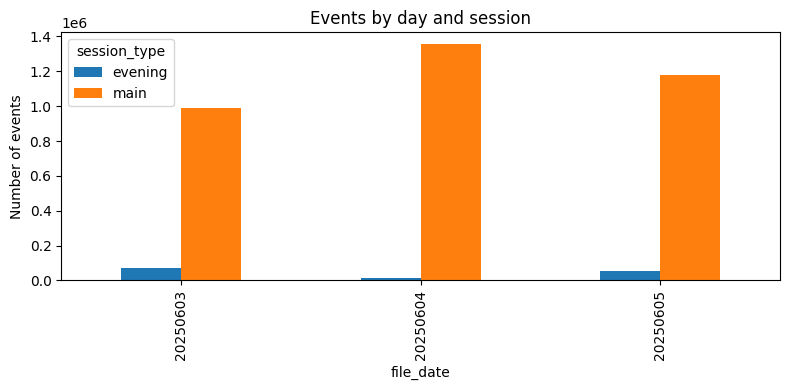

In [14]:
tmp = (
    session_counts
    .pivot(index="file_date", columns="session_type", values="n_events")
    .fillna(0)
    .sort_index()
)

ax = tmp.plot(kind="bar", figsize=(8, 4))
ax.set_title("Events by day and session")
ax.set_ylabel("Number of events")
plt.tight_layout()
plt.show()

#### Select experimental subset

In [15]:
exp_df = df.loc[
    (df["file_date"].astype(str) == cfg["experiment"]["file_date"]) &
    (df["session_type"] == cfg["experiment"]["session_type"])
].copy()

print("Experiment mode:", cfg["experiment"]["mode"])
print("Selected file_date:", cfg["experiment"]["file_date"])
print("Selected session_type:", cfg["experiment"]["session_type"])
print("Experiment subset shape:", exp_df.shape)

exp_df[["file_date", "session_type"]].value_counts()

Experiment mode: single_session
Selected file_date: 20250603
Selected session_type: main
Experiment subset shape: (987938, 100)


file_date  session_type
20250603   main            987938
Name: count, dtype: int64

#### Subset sanity check

In [16]:
display(exp_df[["event_dt", "file_date", "session_type", "session_id"]].head())
display(exp_df[["event_dt", "file_date", "session_type", "session_id"]].tail())

print("Unique session_id:", exp_df["session_id"].nunique())
print(exp_df["session_id"].value_counts())

,event_dt,file_date,session_type,session_id
73564,2025-06-03 09:00:00.153000000,20250603,main,20250603_main
73565,2025-06-03 09:00:00.390000000,20250603,main,20250603_main
73566,2025-06-03 09:00:00.767000000,20250603,main,20250603_main
73567,2025-06-03 09:00:01.003000002,20250603,main,20250603_main
73568,2025-06-03 09:00:01.053000000,20250603,main,20250603_main


,event_dt,file_date,session_type,session_id
1061497,2025-06-03 18:49:57.207000000,20250603,main,20250603_main
1061498,2025-06-03 18:49:57.283000002,20250603,main,20250603_main
1061499,2025-06-03 18:49:58.393000002,20250603,main,20250603_main
1061500,2025-06-03 18:49:59.343000002,20250603,main,20250603_main
1061501,2025-06-03 18:49:59.777000000,20250603,main,20250603_main


Unique session_id: 1
session_id
20250603_main    987938
Name: count, dtype: int64


#### Experiment-subset audit

In [17]:
exp_audit_report = {
    "n_rows": len(exp_df),
    "n_cols": exp_df.shape[1],
    "event_dt_min": exp_df["event_dt"].min(),
    "event_dt_max": exp_df["event_dt"].max(),
    "spread_mean": float(exp_df["spread"].mean()),
    "spread_median": float(exp_df["spread"].median()),
    "reversed_book_share": float((exp_df["best_ask_price"] < exp_df["best_bid_price"]).mean()),
}

exp_audit_report

{'n_rows': 987938,
 'n_cols': 100,
 'event_dt_min': Timestamp('2025-06-03 09:00:00.153000'),
 'event_dt_max': Timestamp('2025-06-03 18:49:59.777000'),
 'spread_mean': 0.0016029335849010715,
 'spread_median': 0.0019999999999988916,
 'reversed_book_share': 0.0}

#### Save `clean.parquet`

In [18]:
save_table(exp_df, cfg["data"]["clean_path"])
print("Saved experiment subset:", cfg["data"]["clean_path"])

Saved experiment subset: outputs/datasets/clean.parquet


#### Save audit tables

In [19]:
tables_dir = Path("outputs/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame([audit_report]).to_csv(tables_dir / "audit_summary_full.csv", index=False)
pd.DataFrame([exp_audit_report]).to_csv(tables_dir / "audit_summary_experiment.csv", index=False)
date_report.to_csv(tables_dir / "file_date_report.csv", index=False)
monotonic_report.to_csv(tables_dir / "monotonicity_report.csv", index=False)
session_counts.to_csv(tables_dir / "session_counts.csv", index=False)
null_report.to_csv(tables_dir / "null_report.csv", index=False)

print("Saved tables to", tables_dir.resolve())

Saved tables to /home/zakhar/PycharmProjects/PythonProject5/outputs/tables


## Key audit findings

- The full dataset contains multiple trading dates, where each file is aligned to a trading date and spans the previous calendar day evening session plus the main session of the trading date.
- Top-of-book data is internally consistent: `mid_price` matches the arithmetic mid exactly, inverted quotes are absent, and spread is almost always positive.
- To keep the modeling stage computationally stable, the main experiment is restricted to the **main trading session of 2025-06-03**, which is explicitly allowed by the assignment.
- This subset corresponds to a single coherent and liquid market regime and is therefore suitable for target construction, baseline comparison, and model ablation under a strict time-ordered split.